## **Explainable Credit Risk Assessment System**

## **Load the Data**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## **Exploratory Data Analysis (EDA)**

#### **Dataset Exploration**

In [4]:
df.shape

(130324, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130324 entries, 0 to 130323
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   person_age                  130324 non-null  int64  
 1   person_income               130324 non-null  int64  
 2   person_home_ownership       130324 non-null  str    
 3   person_emp_length           126683 non-null  float64
 4   loan_intent                 130324 non-null  str    
 5   loan_grade                  130324 non-null  str    
 6   loan_amnt                   130324 non-null  int64  
 7   loan_int_rate               117776 non-null  float64
 8   loan_status                 130324 non-null  int64  
 9   loan_percent_income         130324 non-null  float64
 10  cb_person_default_on_file   130324 non-null  str    
 11  cb_person_cred_hist_length  130324 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 14.1 MB


In [6]:
df.describe(include='all')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,130324.000000,1.303240e+05,130324,126683.000000,130324,130324,130324.000000,117776.000000,130324.000000,130324.000000,130324,130324.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,65784,NaN,25812,43108,NaN,NaN,NaN,NaN,107344,NaN
mean,27.741414,6.632856e+04,NaN,4.734621,NaN,NaN,9613.857578,11.012863,0.218164,0.172978,NaN,5.809782
std,6.427606,6.480682e+04,NaN,3.968247,NaN,NaN,6349.261140,3.214906,0.413001,0.122039,NaN,4.064022
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.851000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.559600e+04,NaN,4.000000,NaN,NaN,8075.000000,11.000000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.925000e+04,NaN,7.000000,NaN,NaN,12550.000000,13.450000,0.000000,0.230000,NaN,8.000000


In [7]:
df.isnull().sum()

person_age                        0
person_income                     0
person_home_ownership             0
person_emp_length              3641
loan_intent                       0
loan_grade                        0
loan_amnt                         0
loan_int_rate                 12548
loan_status                       0
loan_percent_income               0
cb_person_default_on_file         0
cb_person_cred_hist_length        0
dtype: int64

In [8]:
df['loan_status'].unique()

array([1, 0])

In [9]:
df.duplicated().sum()

np.int64(165)

In [10]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

#### **Univariate Analysis**

##### **Target Variable (loan_status)**

C:\Users\aduet\AppData\Local\Temp\ipykernel_17824\1880799458.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="loan_status", palette=["#2ecc71", "#e74c3c"])


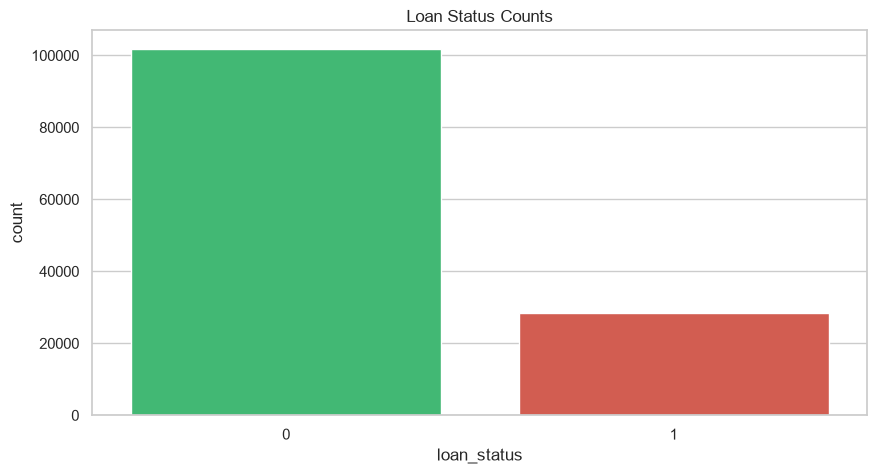

In [11]:
# 1. Target distribution: Non-Default (0) vs Default (1)
fig, ax = plt.subplots()

sns.countplot(data=df, x="loan_status", palette=["#2ecc71", "#e74c3c"])
ax.set_title("Loan Status Counts")

plt.show()

##### **Numerical Distributions**

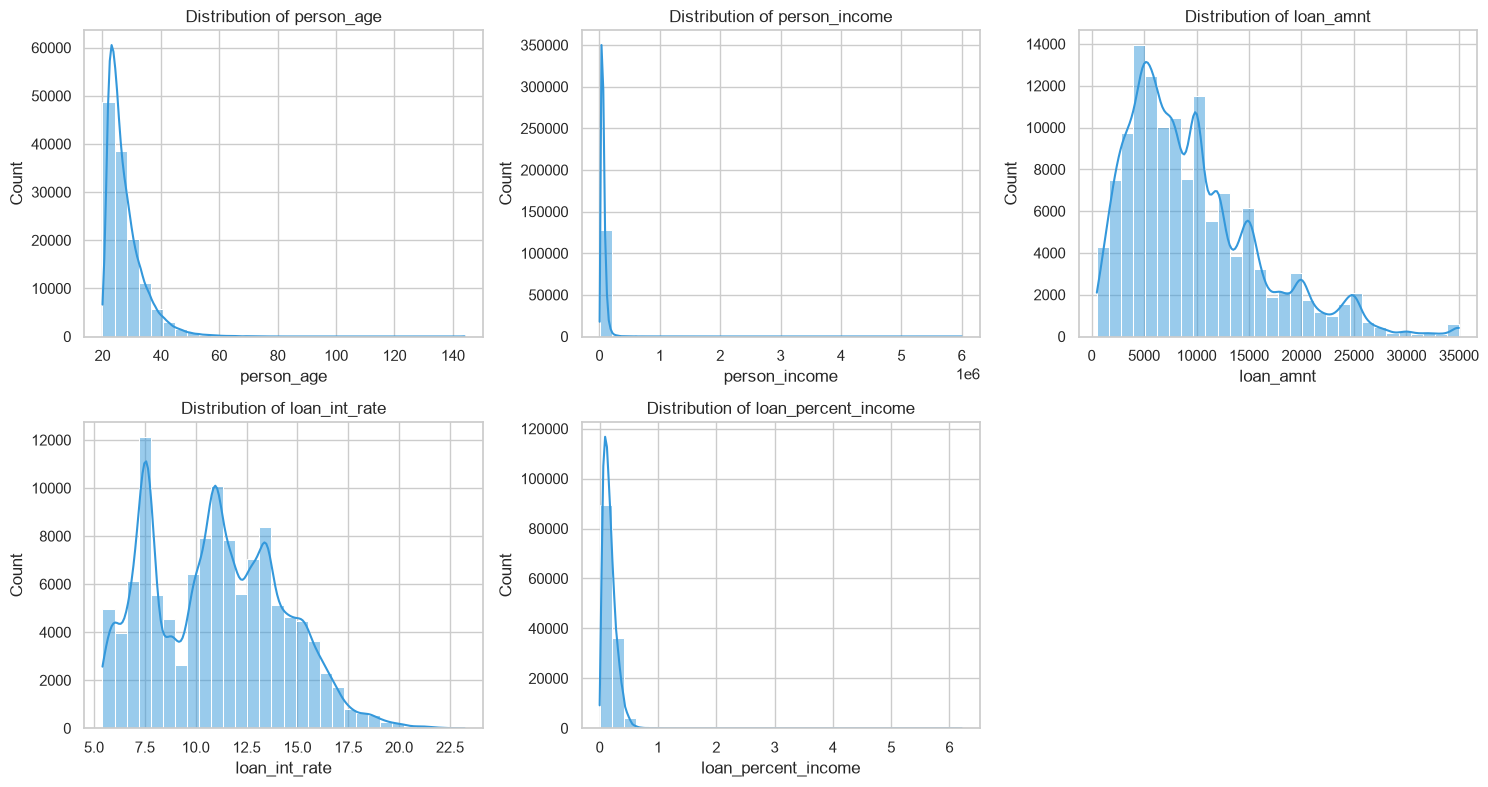

In [12]:
# Histograms with KDE for key numerical variables
num_cols = ["person_age", "person_income", "loan_amnt", "loan_int_rate", "loan_percent_income"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i], color="#3498db")
    axes[i].set_title(f"Distribution of {col}")

# Hide the unused 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


##### **Categorical Features**

C:\Users\aduet\AppData\Local\Temp\ipykernel_17824\3391618080.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Blues_r", ax=axes[i])
C:\Users\aduet\AppData\Local\Temp\ipykernel_17824\3391618080.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Blues_r", ax=axes[i])
C:\Users\aduet\AppData\Local\Temp\ipykernel_17824\3391618080.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Blues_r", ax=axes[i])
C:\Users\aduet\AppData

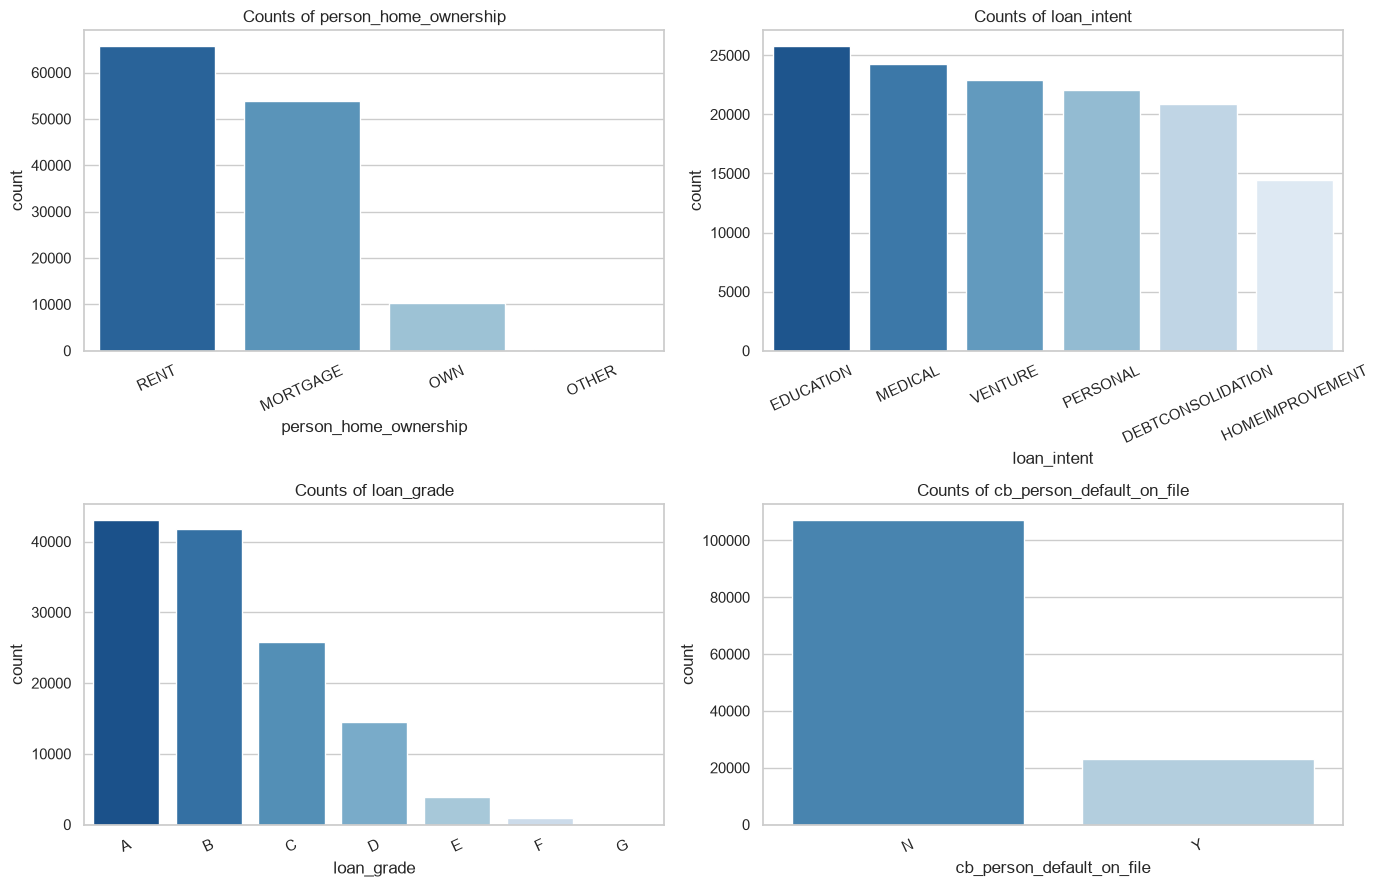

In [13]:
# Frequency countplots for categorical variables
cat_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette="Blues_r", ax=axes[i])
    axes[i].set_title(f"Counts of {col}")
    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


#### **Bivariate Analysis**

##### **Default rate by Categorical Factors**

C:\Users\aduet\AppData\Local\Temp\ipykernel_17824\574247797.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_rate, x=col, y="default_percent", palette="Reds_r", ax=axes[i])
C:\Users\aduet\AppData\Local\Temp\ipykernel_17824\574247797.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_rate, x=col, y="default_percent", palette="Reds_r", ax=axes[i])
C:\Users\aduet\AppData\Local\Temp\ipykernel_17824\574247797.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_rate, x=col, y="default_percent", palette

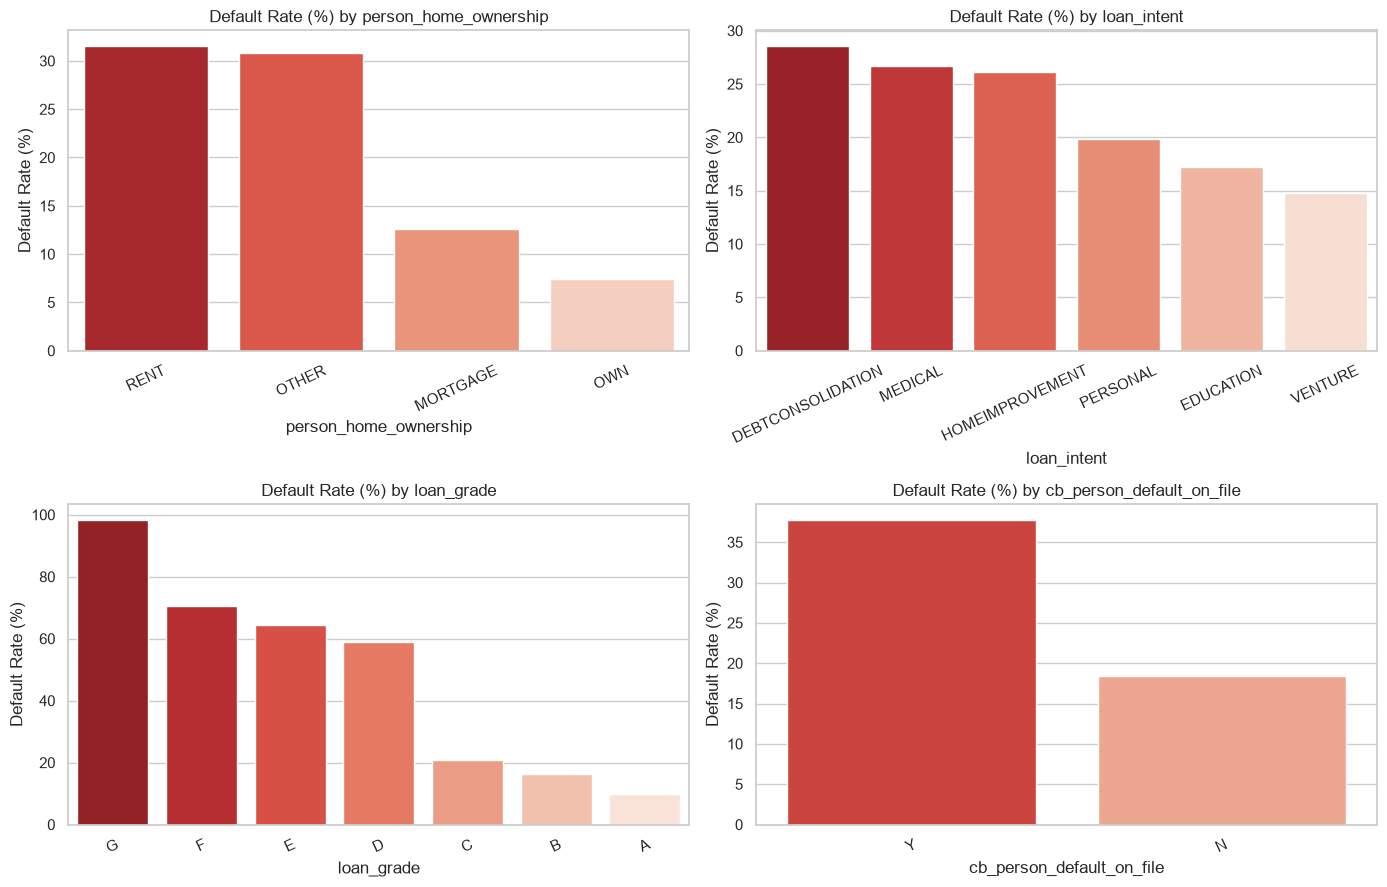

In [14]:
# Default rate (%) by Loan Grade, Loan Intent, Home Ownership, and Default History
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)["loan_status"].mean().reset_index()
    default_rate["default_percent"] = default_rate["loan_status"] * 100
    default_rate = default_rate.sort_values(by="default_percent", ascending=False)
    
    sns.barplot(data=default_rate, x=col, y="default_percent", palette="Reds_r", ax=axes[i])
    axes[i].set_title(f"Default Rate (%) by {col}")
    axes[i].set_ylabel("Default Rate (%)")
    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


##### **Key Numerics vs loan_status**

C:\Users\aduet\AppData\Local\Temp\ipykernel_17824\4273401368.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="loan_status", y=col, palette=["#2ecc71", "#e74c3c"], ax=axes[i], showfliers=False)
C:\Users\aduet\AppData\Local\Temp\ipykernel_17824\4273401368.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(["Non-Default (0)", "Default (1)"])
C:\Users\aduet\AppData\Local\Temp\ipykernel_17824\4273401368.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="loan_status", y=col, palette=["#2ecc71", "#e74c3c"], ax=axes[i], showfli

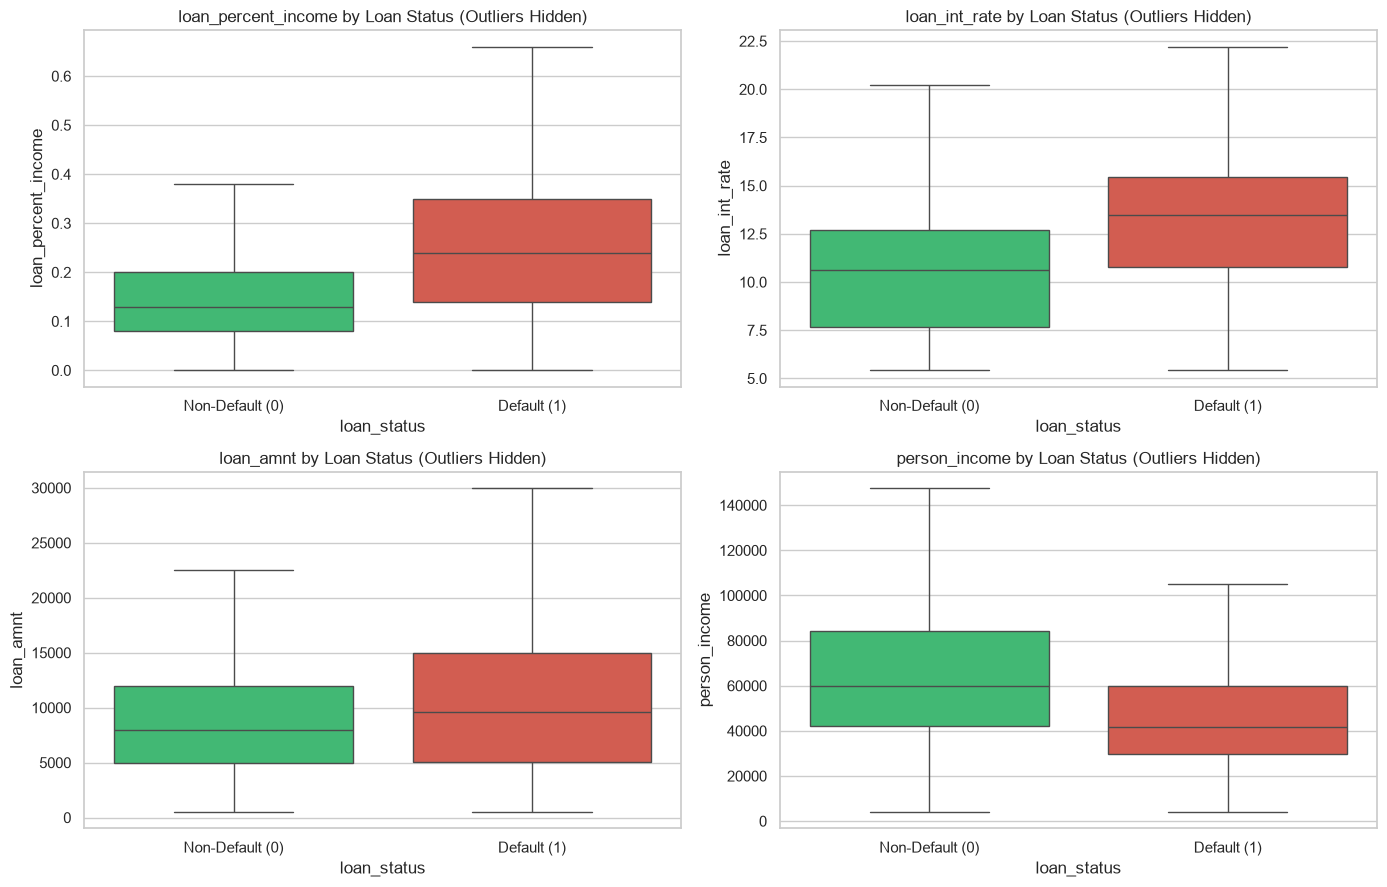

In [15]:
# Boxplots comparing key metrics between Non-Default (0) and Default (1)
features_to_compare = ["loan_percent_income", "loan_int_rate", "loan_amnt", "person_income"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(features_to_compare):
    sns.boxplot(data=df, x="loan_status", y=col, palette=["#2ecc71", "#e74c3c"], ax=axes[i], showfliers=False)
    axes[i].set_xticklabels(["Non-Default (0)", "Default (1)"])
    axes[i].set_title(f"{col} by Loan Status (Outliers Hidden)")

plt.tight_layout()
plt.show()


#### **Outlier Detection**

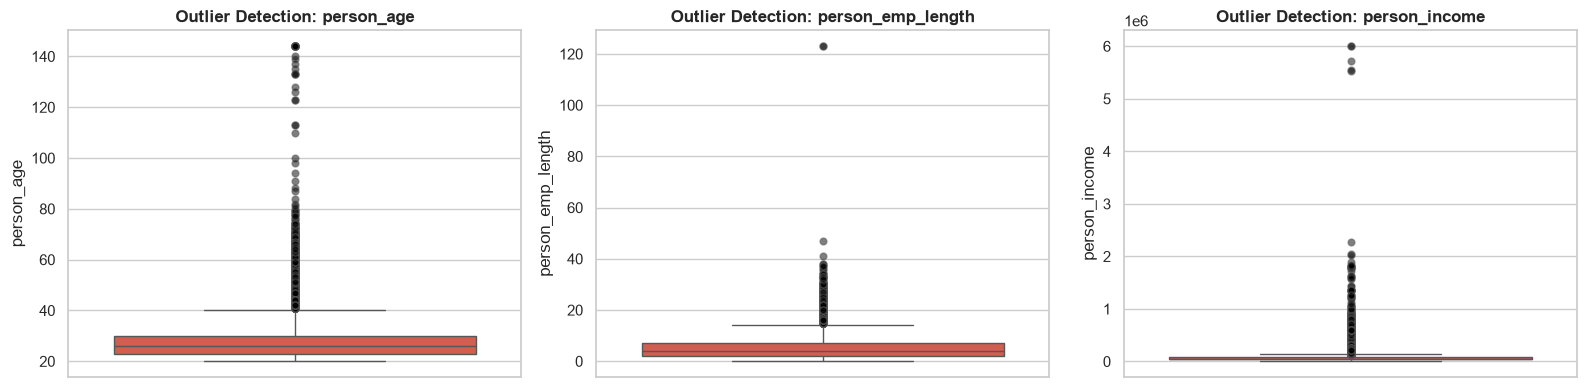

In [16]:
# Boxplots focusing on extreme values and outliers
outlier_features = ["person_age", "person_emp_length", "person_income"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(outlier_features):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        color="#e74c3c", 
        flierprops={"marker": "o", "markersize": 5, "markerfacecolor": "black", "alpha": 0.5}
    )
    axes[i].set_title(f"Outlier Detection: {col}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


Age Percentiles:
0.25     23.0
0.50     26.0
0.75     30.0
0.95     40.0
0.99     50.0
1.00    144.0
Name: person_age, dtype: float64


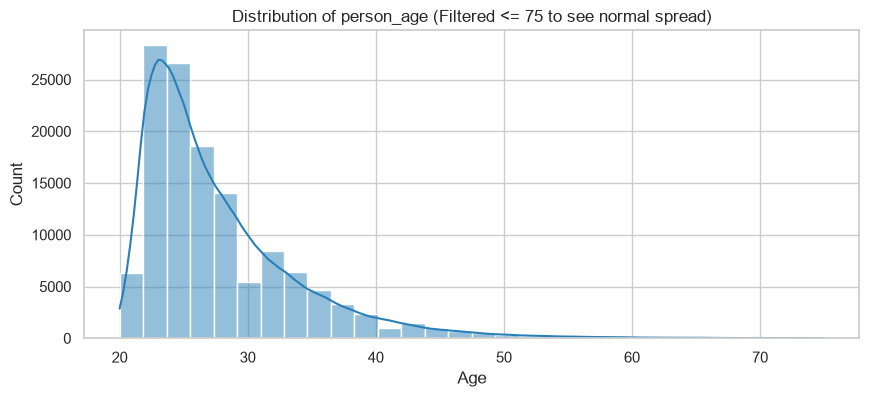

In [17]:
# 1. Summary statistics for age
print("Age Percentiles:")
print(df["person_age"].quantile([0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))

# 3. Age distribution zoomed in: Normal range (<= 75) vs Extreme (> 75)
plt.figure(figsize=(10, 4))
sns.histplot(df[df["person_age"] <= 75]["person_age"], bins=30, kde=True, color="#2980b9")
plt.title("Distribution of person_age (Filtered <= 75 to see normal spread)", fontsize=12)
plt.xlabel("Age")
plt.show()


In [18]:
(df['person_age'] > 100).sum()

np.int64(26)

In [19]:
# In real life:
# - A person cannot have employment length greater than their age
# - A person cannot have credit history longer than their age

emp_gt_age = df[df["person_emp_length"] > df["person_age"]]
cred_gt_age = df[df["cb_person_cred_hist_length"] > df["person_age"]]
emp_gt_60 = df[df["person_emp_length"] > 60]

print(f"Records where employment length > age : {len(emp_gt_age)}")
print(f"Records where credit history > age    : {len(cred_gt_age)}")
print(f"Records where employment length > 60  : {len(emp_gt_60)}")

# Display the impossible employment records
if len(emp_gt_age) > 0:
    print("\nSample records where employment length > age:")
    display(emp_gt_age[["person_age", "person_emp_length", "person_income", "loan_amnt"]])


Records where employment length > age : 2
Records where credit history > age    : 0
Records where employment length > 60  : 2

Sample records where employment length > age:


,person_age,person_emp_length,person_income,loan_amnt
0,22,123.0,59000,35000
210,21,123.0,192000,20000


##### **Statistical IQR Outlier Summary for All Numerical Columns**

In [20]:
# Standard 1.5 * IQR outlier detection table
outlier_summary = []

for col in df.select_dtypes(include=["number"]).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    num_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    pct_outliers = (num_outliers / len(df)) * 100
    
    outlier_summary.append({
        "Feature": col,
        "Min": df[col].min(),
        "Max": df[col].max(),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": num_outliers,
        "Outlier %": f"{pct_outliers:.2f}%"
    })

pd.DataFrame(outlier_summary)

,Feature,Min,Max,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,person_age,20.00,144.00,12.50,40.50,6030,4.63%
1,person_income,4000.00,6000000.00,-22600.00,140360.00,6137,4.71%
2,person_emp_length,0.00,123.00,-5.50,14.50,3173,2.43%
3,loan_amnt,500.00,35000.00,-6325.00,23875.00,5804,4.45%
4,loan_int_rate,5.42,23.22,-0.42,21.78,25,0.02%
5,loan_status,0.00,1.00,0.00,0.00,28432,21.82%
6,loan_percent_income,0.00,6.21,-0.12,0.44,3227,2.48%
7,cb_person_cred_hist_length,2.00,34.00,-4.50,15.50,4447,3.41%


#### **Correlation Heatmap**

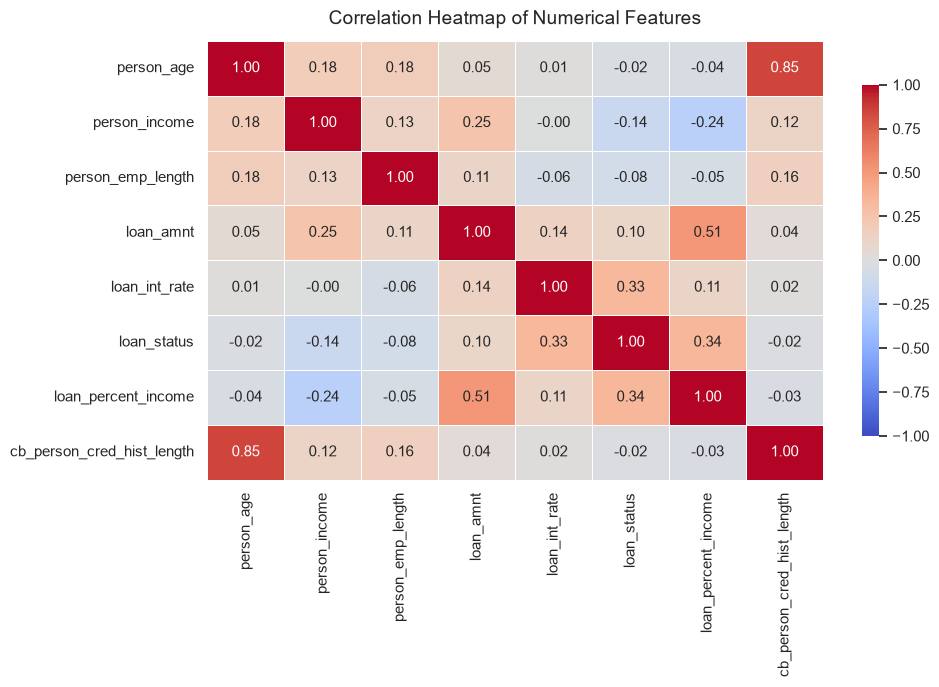

In [21]:
# Correlation matrix of numerical variables
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, pad=12)
plt.tight_layout()
plt.show()


## **Data Validation and Outlier Handling**

- Here we clean the data properly.
- We remove duplicate rows.
- We remove rows with an impossible age or work experience.
- We remove rows with zero or negative income and loan amount.

In [27]:
df_copy = df.copy()

print(f"Original Rows: {df_copy.shape[0]}")

#Remove Duplicate rows 
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

#Remove ages below 18 or above 100
df_copy = df_copy[df_copy['person_age'] >=18]
df_copy = df_copy[df_copy['person_age'] <=100]
print(f"Rows after removing ages below 18 and above 100 : {df_copy.shape[0]}")

#Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]
print(f"Rows after removing employment length greater than age : {df_copy.shape[0]}")

#Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]
print(f"Rows after removing 0 or negative income/loan amount : {df_copy.shape[0]}")

#check if the interest rate looks realistic.
print("Loan interest rate range from (min: 5.42 and max: 23.22)")

Original Rows: 130324
Rows after removing duplicates : 130159
Rows after removing ages below 18 and above 100 : 130133
Rows after removing employment length greater than age : 126498
Rows after removing 0 or negative income/loan amount : 126498
Loan interest rate range from (min: 5.42 and max: 23.22)


## **Features, Target and Train/Test Split**

In [23]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status'] #1, 0

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [25]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## **Handle Class Imbalance**

In [29]:
#0 -> no loan (most)
#1 -> yes loan

neg, pos = np.bincount(y_train)
scale_weights = neg/pos

In [30]:
scale_weights

np.float64(3.59364502950522)

## **Data Preprocessing - Pipelines & Column Transformer**

#### **Preprocessing for Logistic Regression**

- Fill missing numeric values.
- Scale numeric values, since this model is sensitive to scale.
- Convert category columns into numbers using one-hot encoding.

In [ ]:
#Logistic Regression : impute + SCALE Numeric, impute + One-Hot Encoding

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #Pipeline - for Categorical cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

In [32]:
preprocessor_lr

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

#### **Preprocessing for XGBoost**

- Fill missing numeric values.
- No scaling needed here, since tree models don't need it.
- Convert category columns into numbers using one-hot encoding.

In [ ]:
#XGBoost: Impute numeric only (No Scaling), impute + One-Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline - for Categorical cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


In [34]:
preprocessor_xg

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## **Evaluation Helper Function**

- We build one common function to check any model's performance.
- It will show accuracy, precision, recall, F1 score, and more.
- It will also show a confusion matrix and a precision-recall curve.

In [35]:
# We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve

def evaluate_model(model_name, model, X_test, y_test, threshold=None):

  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  # Metrics
  accuracy     = accuracy_score(y_test, y_pred)    # Overall model's preformance
  precision    = precision_score(y_test, y_pred)   # When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      # of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          # Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")

  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot = True, fmt = "d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()
     

## **Stratified Cross-Validation**

- One single train-test split may not be reliable.
- We split the training data into five folds instead.
- Each fold keeps the same default vs repaid ratio.
- We check the model's score across all folds.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter = 1000, 
        class_weight = "balanced", 
        random_state = 42))
])

In [38]:
# XGboost Model

from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator = 300, 
        max_depth = 5, 
        learning_rate = 0.1,
        scale_pos_weight = scale_weights,
        random_state = 42
    ))
])

In [39]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline), ("XGBoost", xgb_cv_pipeline)]:
    cv_results = cross_validate(pipe, X_train , y_train, cv = cv, scoring = scoring, n_jobs = -1)

    print(cv_name)
    print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
    print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
    print(f"Precision : {cv_results['test_precision'].mean()}")
    print(f"Recall : {cv_results['test_recall'].mean()}")
    print(f"F1 : {cv_results['test_f1'].mean()}")
    print()

Logistic Regression
ROC-AUC : 0.8664449493064378
Accuracy : 0.810006167406215
Precision : 0.545023951712213
Recall : 0.7706763504312301
F1 : 0.6384810077455596

XGBoost
ROC-AUC : 0.928859342887202
Accuracy : 0.8908575497117743
Precision : 0.7364390783649333
Recall : 0.776713572401271
F1 : 0.7560102095553642



## **Baseline Model - Logistic Regression**